# Transformer Evaluation

Load a saved triple-barrier Transformer checkpoint, build an evaluation dataset for a selected candle timeframe, run inference, and plot confusion matrices.

In [11]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PACKAGE_SRC = PROJECT_ROOT / "packages" / "src"
if str(PACKAGE_SRC) not in sys.path:
    sys.path.insert(0, str(PACKAGE_SRC))

PROJECT_ROOT

PosixPath('/Users/akash/PycharmProjects/AlgoTrade')

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader

from tradingbot.models import TransformerWindowDataset, build_transformer

DATA_DIR = PROJECT_ROOT / "data" / "historic_candle_feature"
MODEL_DIR = PROJECT_ROOT / "data" / "models"

MODEL_CHECKPOINT_PATH = None
# MODEL_DIR / "triple_barrier_transformer_classification_AXISBANK_15minute_20260516_022110_valacc_0.6600.pt"  
# # set an explicit .pt path, or leave None to use the latest matching checkpoint
MODEL_CHECKPOINT_GLOB = "triple_barrier_transformer*.pt"

TIMEFRAME = "15minute"
EVAL_STOCKS = ["ADANIPORTS"]  # set None for every stock in the timeframe, or e.g. ["AXISBANK", "HDFCBANK"]
FILE_SUFFIX = "features_triple_barrier.csv"

BATCH_SIZE = 256
MAX_ROWS_PER_FILE = None

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DEVICE

device(type='mps')

In [13]:
def resolve_checkpoint():
    if MODEL_CHECKPOINT_PATH is not None:
        path = Path(MODEL_CHECKPOINT_PATH)
        if not path.exists():
            raise FileNotFoundError(path)
        return path

    candidates = sorted(
        MODEL_DIR.glob(MODEL_CHECKPOINT_GLOB),
        key=lambda path: path.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(f"No checkpoints found at {MODEL_DIR / MODEL_CHECKPOINT_GLOB}")
    return candidates[-1]


checkpoint_path = resolve_checkpoint()
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model_config = checkpoint["model_config"]
if model_config.get("output_type") != "classification":
    raise ValueError("Confusion matrices are only available for classification checkpoints.")

feature_columns = model_config.get("feature_columns") or checkpoint.get("feature_columns")
label_columns = checkpoint.get("label_columns") or [
    "triple_barrier_label_lower",
    "triple_barrier_label_neutral",
    "triple_barrier_label_upper",
]
context_length = checkpoint.get("context_length", 64)
target_offset = checkpoint.get("target_offset", 0)

if not feature_columns:
    raise ValueError("Checkpoint does not include feature_columns.")

{
    "checkpoint": checkpoint_path.name,
    "feature_count": len(feature_columns),
    "labels": label_columns,
    "context_length": context_length,
    "target_offset": target_offset,
}

{'checkpoint': 'triple_barrier_transformer.pt',
 'feature_count': 21,
 'labels': ['triple_barrier_label_lower',
  'triple_barrier_label_neutral',
  'triple_barrier_label_upper'],
 'context_length': 128,
 'target_offset': 0}

In [14]:
def labelled_files_for_timeframe(timeframe, stocks=None):
    if stocks is None:
        return sorted(DATA_DIR.glob(f"*_{timeframe}_*_{FILE_SUFFIX}"))

    files = []
    missing = []
    for stock in stocks:
        matches = sorted(DATA_DIR.glob(f"{stock}_{timeframe}_*_{FILE_SUFFIX}"))
        if matches:
            files.extend(matches)
        else:
            missing.append(stock)
    if missing:
        raise FileNotFoundError(f"No {timeframe} labelled feature files found for: {missing}")
    return files


eval_files = labelled_files_for_timeframe(TIMEFRAME, EVAL_STOCKS)
if not eval_files:
    raise FileNotFoundError(f"No labelled feature files found for timeframe={TIMEFRAME}")

schema = pd.read_csv(eval_files[0], nrows=0).columns.tolist()
missing_features = [column for column in feature_columns if column not in schema]
missing_labels = [column for column in label_columns if column not in schema]
if missing_features or missing_labels:
    raise ValueError(
        f"Dataset schema does not match checkpoint. Missing features={missing_features}, missing labels={missing_labels}"
    )

pd.DataFrame({"eval_file": [path.name for path in eval_files]})

,eval_file
0,ADANIPORTS_15minute_1990-01-01T00-00-00plus05-...


In [15]:
eval_dataset = TransformerWindowDataset(
    eval_files,
    feature_columns=feature_columns,
    context_length=context_length,
    label_columns=label_columns,
    target_mode="class_index",
    target_offset=target_offset,
    max_rows_per_file=MAX_ROWS_PER_FILE,
)
if len(eval_dataset) == 0:
    raise ValueError(f"Evaluation dataset is empty. Skipped files: {eval_dataset.skipped[:5]}")

eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)

{
    "eval_windows": len(eval_dataset),
    "label_counts": None if eval_dataset.label_counts is None else eval_dataset.label_counts.tolist(),
    "skipped": eval_dataset.skipped[:5],
}

{'eval_windows': 69410, 'label_counts': [37363, 332, 31715], 'skipped': []}

In [16]:
def transformer_builder_config(config):
    allowed_keys = {
        "input_dim",
        "model_dim",
        "num_heads",
        "num_layers",
        "dropout",
        "output_dim",
        "output_classes",
        "output_type",
        "architecture",
        "ffn_multiplier",
    }
    return {key: value for key, value in config.items() if key in allowed_keys}


model = build_transformer(**transformer_builder_config(model_config)).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

sum(parameter.numel() for parameter in model.parameters())

30819

In [17]:
@torch.no_grad()
def predict_all(model, loader):
    y_true_parts = []
    y_pred_parts = []
    probability_parts = []

    for x, y in loader:
        x = x.to(DEVICE)
        logits = model(x)
        probabilities = torch.softmax(logits, dim=-1).cpu()
        predictions = probabilities.argmax(dim=-1)

        y_true_parts.append(y.cpu())
        y_pred_parts.append(predictions)
        probability_parts.append(probabilities)

    return (
        torch.cat(y_true_parts),
        torch.cat(y_pred_parts),
        torch.cat(probability_parts),
    )


def confusion_matrix(y_true, y_pred, class_count):
    matrix = torch.zeros((class_count, class_count), dtype=torch.int64)
    for actual, predicted in zip(y_true, y_pred):
        matrix[int(actual), int(predicted)] += 1
    return matrix


y_true, y_pred, probabilities = predict_all(model, eval_loader)
confusion = confusion_matrix(y_true, y_pred, len(label_columns))
accuracy = (y_true == y_pred).float().mean().item()

pd.DataFrame(
    confusion.numpy(),
    index=[f"actual:{label}" for label in label_columns],
    columns=[f"pred:{label}" for label in label_columns],
)

,pred:triple_barrier_label_lower,pred:triple_barrier_label_neutral,pred:triple_barrier_label_upper
actual:triple_barrier_label_lower,29303,123,7937
actual:triple_barrier_label_neutral,7,305,20
actual:triple_barrier_label_upper,4116,79,27520


In [18]:
def classification_report_from_confusion(matrix, labels):
    matrix = matrix.to(torch.float32)
    true_positive = matrix.diag()
    false_positive = matrix.sum(dim=0) - true_positive
    false_negative = matrix.sum(dim=1) - true_positive

    precision = true_positive / (true_positive + false_positive).clamp_min(1)
    recall = true_positive / (true_positive + false_negative).clamp_min(1)
    f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-12)
    support = matrix.sum(dim=1)

    report = pd.DataFrame(
        {
            "precision": precision.tolist(),
            "recall": recall.tolist(),
            "f1": f1.tolist(),
            "support": support.tolist(),
        },
        index=labels,
    )
    report.loc["macro_avg"] = [
        precision.mean().item(),
        recall.mean().item(),
        f1.mean().item(),
        support.sum().item(),
    ]
    report.loc["accuracy"] = [accuracy, accuracy, accuracy, support.sum().item()]
    return report


classification_report_from_confusion(confusion, label_columns)

,precision,recall,f1,support
triple_barrier_label_lower,0.876653,0.784279,0.827897,37363.0
triple_barrier_label_neutral,0.601578,0.918675,0.727056,332.0
triple_barrier_label_upper,0.775714,0.867728,0.819145,31715.0
macro_avg,0.751315,0.856894,0.791366,69410.0
accuracy,0.823051,0.823051,0.823051,69410.0


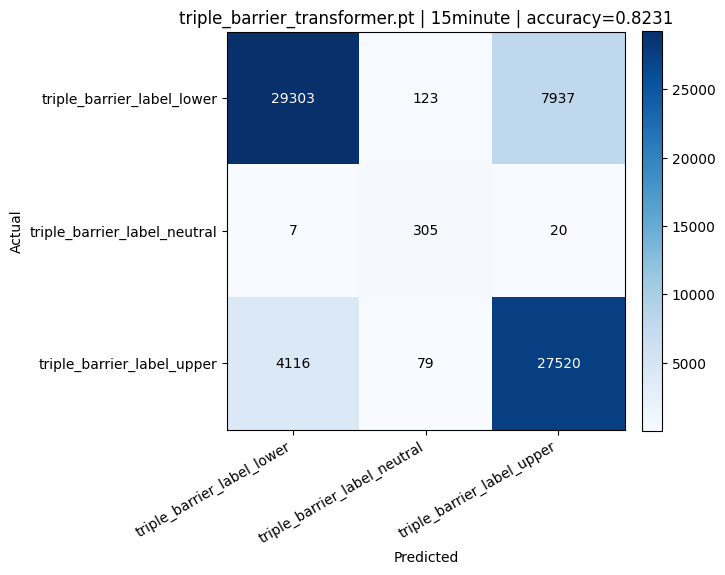

In [19]:
def plot_confusion_matrix(matrix, labels, *, normalize=False, title=None):
    values = matrix.to(torch.float32)
    if normalize:
        values = values / values.sum(dim=1, keepdim=True).clamp_min(1)

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(values.numpy(), cmap="Blues")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title or ("Normalized Confusion Matrix" if normalize else "Confusion Matrix"))

    threshold = values.max().item() / 2 if values.numel() else 0
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            value = values[row, column].item()
            text = f"{value:.2f}" if normalize else str(int(matrix[row, column].item()))
            color = "white" if value > threshold else "black"
            ax.text(column, row, text, ha="center", va="center", color=color)

    fig.tight_layout()
    return fig, ax


plot_confusion_matrix(
    confusion,
    label_columns,
    title=f"{checkpoint_path.name} | {TIMEFRAME} | accuracy={accuracy:.4f}",
);

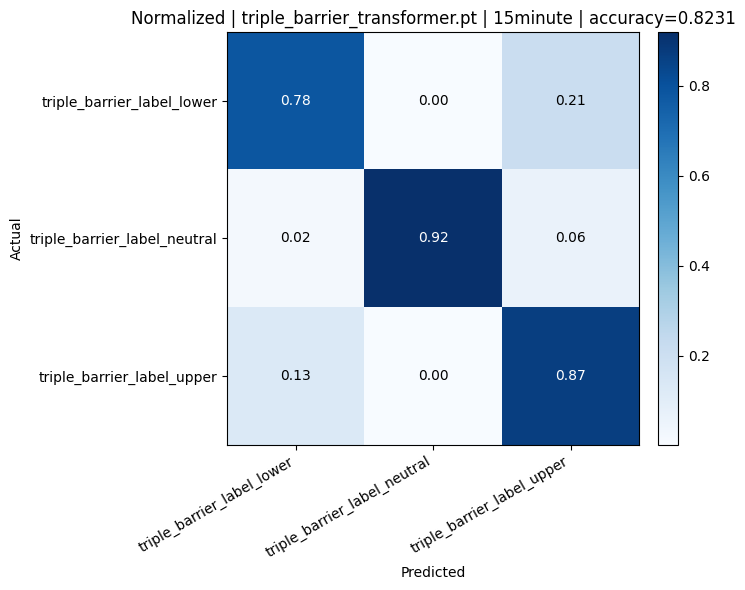

In [20]:
plot_confusion_matrix(
    confusion,
    label_columns,
    normalize=True,
    title=f"Normalized | {checkpoint_path.name} | {TIMEFRAME} | accuracy={accuracy:.4f}",
);